## Nome: Caio Semblano Silva
## Matrícula: 621

# Atividade 6 — Refinamento de Raízes: Método de Newton-Raphson
## Contexto: Nós de uma Função de Onda Quântica

Na disciplina de F04 (Física Moderna e Quântica), os **nós de uma função de onda** representam posições nas quais a amplitude de probabilidade é nula. Em um modelo simplificado relacionado ao oscilador harmônico quântico, a parte polinomial de uma função de onda pode ser representada por:

$$\psi(x)=4x^3-6x$$

Para aplicar o método de Newton-Raphson, utiliza-se sua derivada:

$${\psi}'(x)=12x^2-6$$

Nesta atividade, o objetivo é localizar numericamente os valores de $x$ para os quais $\psi(x)=0$ e analisar como o chute inicial e a tolerância influenciam a convergência.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 4*x**3 - 6*x

def df(x):
    return 12*x**2 - 6

In [3]:
def newton_raphson(x0, tol=1e-9, max_iter=100):
    x = x0
    for i in range(max_iter):
        if abs(f(x)) < tol:
            return x, i
        if abs(df(x)) < 1e-12:
            raise ValueError("Derivada muito próxima de zero. Escolha outro chute inicial.")
        x = x - f(x)/df(x)
    return x, max_iter

## Parte Prática
1. Plote $f(x)$ no intervalo $[-2;2]$, indicando com uma linha tracejada o eixo $y=0$ e identificando visualmente as possíveis raízes.

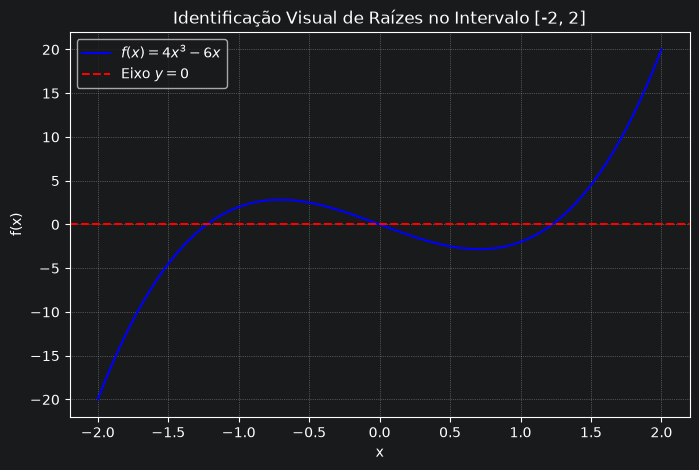

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 400)
y = f(x)

plt.figure(figsize=(8, 5))

plt.plot(x, y, label='$f(x) = 4x^3 - 6x$', color='blue')

plt.axhline(0, color='red', linestyle='--', label='Eixo $y=0$')

plt.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Identificação Visual de Raízes no Intervalo [-2, 2]')
plt.legend()

plt.show()

2. Aplique o método de Newton-Raphson utilizando o chute inicial $x_0=1{,}8$. Apresente a raiz aproximada e o número de iterações.

In [5]:
x0 = 1.8

raiz, iteracoes = newton_raphson(x0)

print(f"Raiz aproximada: {raiz}")
print(f"Número de iterações: {iteracoes}")

Raiz aproximada: 1.2247448713969942
Número de iterações: 5


3. Teste os chutes iniciais $(-2{,}0; -1{,}0; -0{,}4; 0{,}2; 0{,}8; 1{,}6)$ e compare a raiz encontrada e o número de iterações em cada caso.

In [20]:
chutes = [-2.0, -1.0, -0.4, 0.2, 0.8, 1.6]

print(f"{'Chute Inicial':<15} | {'Raiz Encontrada':<18} | {'Iterações'}")
print("-" * 50)

for x0 in chutes:
    try:
        raiz, it = newton_raphson(x0)
        print(f"{x0:<15.1f} | {float(raiz):<18.6f} | {it}")
    except ValueError as e:
        print(f"{x0:<15.1f} | Erro: {e}")

Chute Inicial   | Raiz Encontrada    | Iterações
--------------------------------------------------
-2.0            | -1.224745          | 6
-1.0            | -1.224745          | 5
-0.4            | -0.000000          | 4
0.2             | -0.000000          | 3
0.8             | 1.224745           | 7
1.6             | 1.224745           | 5


4. Execute o método com as tolerâncias $10^{-3}$, $10^{-6}$ e $10^{-9}$, mantendo $x_0=1{,}8$. Analise o impacto da tolerância na aproximação da raiz e no número de iterações.

In [18]:
tolerancias = [1e-3, 1e-6, 1e-9]
x0_fixo = 1.8

print(f"{'Tolerância':<12} | {'Raiz Encontrada':<20} | {'Iterações'}")
print("-" * 52)

for tol in tolerancias:
    raiz, it = newton_raphson(x0_fixo, tol=tol)
    print(f"{tol:<12.0e} | {float(raiz):<20.1f} | {it}")

Tolerância   | Raiz Encontrada      | Iterações
----------------------------------------------------
1e-03        | 1.224746972187198    | 4
1e-06        | 1.224744871396994    | 5
1e-09        | 1.224744871396994    | 5


## Parte Teórica

1. O que significa afirmar que o método de Newton-Raphson possui convergência quadrática próximo de uma raiz simples?

**Resposta:**
    Afirmar que o método possui convergência quadrática significa que, uma vez que a sua aproximação ($x_k$) se aproxima da verdadeira raiz da função, o erro da próxima iteração ($E_{k+1}$) torna-se proporcional ao quadrado do erro da iteração atual ($E_k$).

2. Como o método pode ser adaptado quando a derivada da função não está disponível analiticamente?

**Resposta:** Quando a derivada $f'(x)$ é muito complexa para ser calculada à mão ou simplesmente não está disponível (como no caso de funções geradas por medições de sensores ou caixas-pretas), o método de Newton-Raphson é tipicamente adaptado para o Método da Secante.

3. Compare o método de Newton-Raphson com o método da bissecção, destacando as vantagens e limitações de cada um.

**Resposta:**

Newton-Raphson: É extremamente rápido (convergência quadrática) e precisa de apenas um ponto de partida (chute inicial). O lado negativo é que ele exige o cálculo da derivada e não tem convergência garantida (o método pode falhar dependendo do chute).

Bissecção: É um método bem mais lento e requer que você conheça previamente um intervalo fechado que contenha a raiz. A grande vantagem é sua confiabilidade, pois possui convergência 100% garantida e não precisa do cálculo de derivadas.

4. Quais problemas podem ocorrer durante a aplicação do método de Newton-Raphson? Cite pelo menos três e relacione um deles à possibilidade de a derivada ser igual ou muito próxima de zero.

**Resposta:**

Três problemas principais: Oscilação infinita, Convergência para raízes muito distantes da área desejada e Falha por derivada nula ou quase nula.

O impacto da derivada quase zero: A fórmula matemática do método exige dividir a função pela sua derivada. Se a derivada for muito próxima de zero, a reta tangente gerada será quase horizontal. Isso faz com que a próxima aproximação seja "arremessada" para um ponto absurdamente distante no gráfico, impossibilitando que o método chegue até a raiz.